In [1]:
import pandas as pd

df = pd.read_json("../../data/raw/meta_Handmade_Products.jsonl", lines=True)
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Handmade,Daisy Keychain Wristlet Gray Fabric Key fob La...,4.5,12,"[High Quality Fabrics, Antique Brass Metallic ...",[This charming Daisy Fabric Keychain wristlet ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Generic,"[Handmade Products, Clothing, Shoes & Accessor...",{'Package Dimensions': '8 x 4 x 0.85 inches; 0...,B07NTK7T5P,NaN
1,Handmade,Anemone Jewelry Beauteous November Birthstone ...,4.1,10,"[Stunning gemstone and detailed design, Bands ...",[Anemone brings this November birthstone ring ...,69.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],Anemone Jewelry,"[Handmade Products, Jewelry, Rings, Statement]","{'Department': 'womens', 'Date First Available...",B0751M85FV,NaN
2,Handmade,Silver Triangle Earrings with Chevron Pattern,5.0,1,[],[These large silver triangles are stamped with...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Zoë Noelle Designs,"[Handmade Products, Jewelry, Earrings, Drop & ...","{'Department': 'Women', 'Date First Available'...",B01HYNE114,NaN
3,Handmade,"Las Vegas Subway Sign Print - Caesar's, Freemo...",1.0,1,[],[Subway Signs make fabulous wall art. A bit of...,19.95,[{'thumb': 'https://m.media-amazon.com/images/...,[],Generic,"[Handmade Products, Home & Kitchen, Artwork, P...","{'Date First Available': 'June 14, 2018'}",B07TKZF3Z1,NaN
4,Handmade,Round Cut Cubic Zirconia Stud Earrings Fashion...,4.2,2,[⭐【Size】The remarkable cubic zirconia studs ha...,[],14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],VDKIDKT,"[Handmade Products, Jewelry, Earrings, Stud]",{'Package Dimensions': '2.36 x 2.05 x 1.65 inc...,B0BKBJT5MM,NaN


In [2]:
df.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together'],
      dtype='str')

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 164817 entries, 0 to 164816
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    164803 non-null  str    
 1   title            164817 non-null  str    
 2   average_rating   164817 non-null  float64
 3   rating_number    164817 non-null  int64  
 4   features         164817 non-null  object 
 5   description      164817 non-null  object 
 6   price            97648 non-null   float64
 7   images           164817 non-null  object 
 8   videos           164817 non-null  object 
 9   store            163699 non-null  str    
 10  categories       164817 non-null  object 
 11  details          164817 non-null  object 
 12  parent_asin      164817 non-null  str    
 13  bought_together  0 non-null       float64
dtypes: float64(3), int64(1), object(6), str(4)
memory usage: 17.6+ MB


,average_rating,rating_number,price,bought_together
count,164817.000000,164817.000000,97648.000000,0.0
mean,4.480380,22.054928,35.135270,NaN
std,0.745277,123.864756,329.869838,NaN
min,1.000000,1.000000,0.010000,NaN
25%,4.200000,2.000000,13.000000,NaN
50%,4.700000,4.000000,19.990000,NaN
75%,5.000000,14.000000,33.900000,NaN
max,5.000000,16370.000000,100000.000000,NaN


In [4]:
df.isnull().sum()

main_category          14
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               67169
images                  0
videos                  0
store                1118
categories              0
details                 0
parent_asin             0
bought_together    164817
dtype: int64

In [5]:
# df["price"] = df["price"].fillna(df["price"].median())
# df["store"] = df["store"].fillna("Unknown")
# df["bought_together"] = df["bought_together"].apply(
#     lambda x: [] if pd.isna(x) else x
# )

In [6]:
df.isnull().sum()

main_category          14
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               67169
images                  0
videos                  0
store                1118
categories              0
details                 0
parent_asin             0
bought_together    164817
dtype: int64

In [7]:
# df = df.drop_duplicates(subset=["parent_asin"])
# df.shape

In [8]:
# df.describe(include='all')

<Axes: xlabel='main_category'>

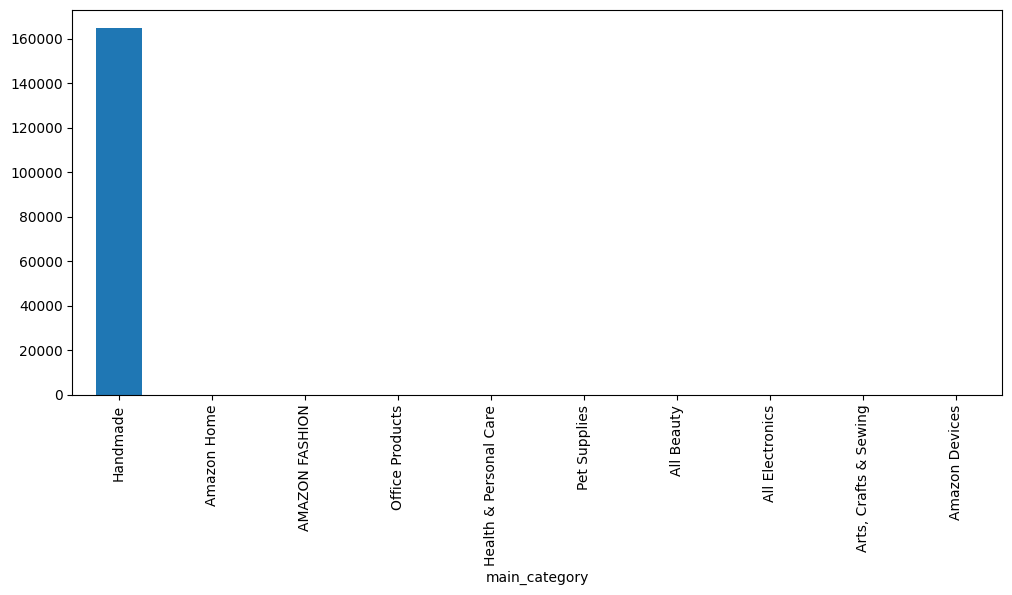

In [9]:
df['main_category'].value_counts().plot(kind='bar', figsize=(12,5))

Text(0.5, 1.0, 'Distribution des prix')

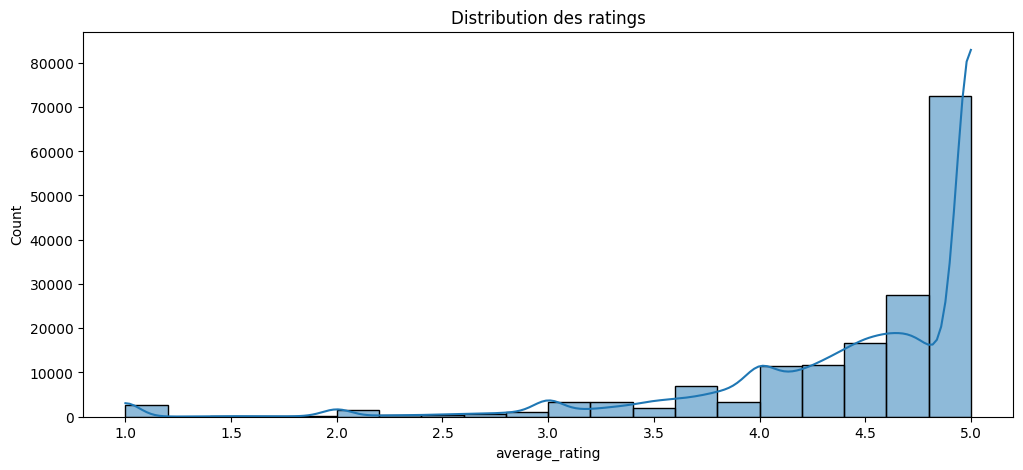

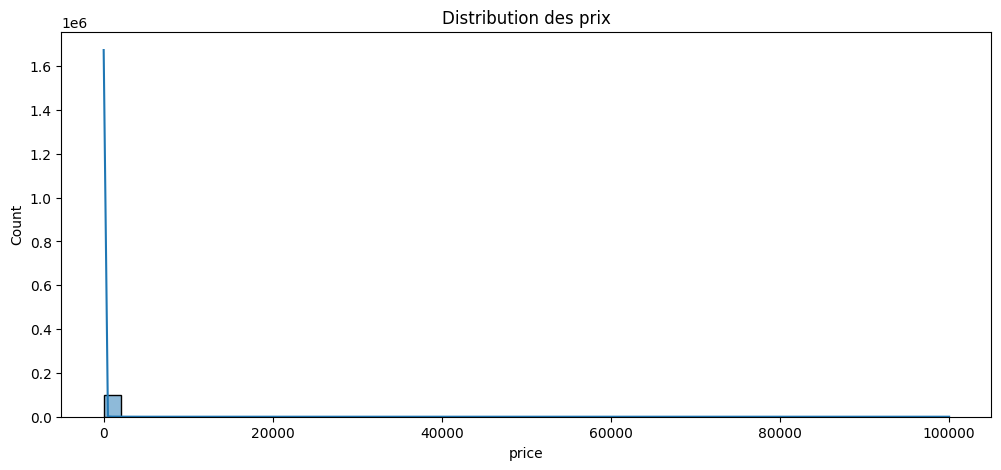

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.histplot(df['average_rating'], bins=20, kde=True)
plt.title("Distribution des ratings")

plt.figure(figsize=(12,5))
sns.histplot(df['price'].dropna(), bins=50, kde=True)
plt.title("Distribution des prix")

In [11]:
import json
import re
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

PRICE_MIN = 3
PRICE_MAX = 500

QUALITY_TIERS = {
    "basic": 1,
    "standard": 2,
    "premium": 3,
    "luxury": 4
}

PACKAGING_TIERS = {
    "none": 0,
    "simple": 1,
    "branded": 2,
    "premium": 3,
    "gift": 4
}

CATEGORY_MULTIPLIERS = {
    "jewelry": 1.5,
    "clothing": 1.3,
    "home": 1.2,
    "beauty": 1.4,
    "art": 1.6,
    "other": 1.0
}

In [12]:
def clean_raw_data(df):

    # Supprimer doublons
    df = df.drop_duplicates(subset=["parent_asin"], keep="first")

    # Nettoyer prix
    df["price"] = pd.to_numeric(
        df["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
        errors="coerce"
    )

    # Remplacer prix null par médiane
    df["price"] = df["price"].fillna(df["price"].median())

    # Filtrer prix réalistes
    df = df[df["price"].between(PRICE_MIN, PRICE_MAX)]

    # Ratings
    df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
    df["average_rating"] = df["average_rating"].clip(1.0, 5.0).fillna(3.5)

    df["rating_number"] = pd.to_numeric(df["rating_number"], errors="coerce").fillna(0)

    # Colonnes texte
    for col in ["title", "description", "main_category"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str)

    # Store → remplacer par "Unknown"
    if "store" in df.columns:
        df["store"] = df["store"].fillna("Unknown")

    # bought_together → remplacer NaN par liste vide
    if "bought_together" in df.columns:
        df["bought_together"] = df["bought_together"].apply(
            lambda x: [] if pd.isna(x) else x
        )

    # Supprimer titres invalides
    df = df[df["title"].str.len() > 3]

    return df.reset_index(drop=True)

In [13]:
def safe_json_parse(val):

    # si valeur vide
    if val is None:
        return {}

    # si c'est déjà une liste ou dict
    if isinstance(val, (list, dict)):
        return val

    # si c'est NaN
    if isinstance(val, float) and pd.isna(val):
        return {}

    # sinon essayer parser JSON
    try:
        return json.loads(str(val).replace("'", '"'))
    except:
        return {}

In [14]:
def parse_complex_columns(df):

    df["features_parsed"] = df["features"].apply(safe_json_parse)

    df["features_text"] = df["features_parsed"].apply(
        lambda x: " ".join(x) if isinstance(x, list) else ""
    )

    df["features_count"] = df["features_parsed"].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    df["details_parsed"] = df["details"].apply(safe_json_parse)

    df["has_certification"] = df["details_parsed"].apply(
        lambda x: 1 if isinstance(x, dict) and "cert" in str(x).lower() else 0
    )

    df["categories_parsed"] = df["categories"].apply(safe_json_parse)

    df["category_depth"] = df["categories_parsed"].apply(
        lambda x: len(x) if isinstance(x, list) else 1
    )

    return df

In [15]:
MATERIAL_KEYWORDS = {
    "silver": ["silver", "925"],
    "gold": ["gold"],
    "cotton": ["cotton"],
    "silk": ["silk"],
    "leather": ["leather"],
    "wood": ["wood"],
    "resin": ["resin"],
    "clay": ["clay"],
    "wool": ["wool"]
}

QUALITY_KEYWORDS = {
    "luxury": ["luxury", "premium", "18k"],
    "premium": ["high quality", "genuine"],
    "standard": ["handmade", "natural"]
}

PACKAGING_KEYWORDS = {
    "gift": ["gift box", "gift wrap"],
    "premium": ["premium packaging"],
    "branded": ["branded box"],
    "simple": ["pouch", "bag"]
}

In [16]:
def extract_text_features(df):

    df["full_text"] = (
        df["title"].fillna("") + " " +
        df["description"].fillna("") + " " +
        df["features_text"].fillna("")
    ).str.lower()

    def detect_material(text):
        for mat, keywords in MATERIAL_KEYWORDS.items():
            if any(k in text for k in keywords):
                return mat
        return "other"

    df["material"] = df["full_text"].apply(detect_material)

    def detect_quality(text):
        for tier, keywords in QUALITY_KEYWORDS.items():
            if any(k in text for k in keywords):
                return QUALITY_TIERS[tier]
        return 2

    df["quality_score"] = df["full_text"].apply(detect_quality)

    def detect_packaging(text):
        for pkg, keywords in PACKAGING_KEYWORDS.items():
            if any(k in text for k in keywords):
                return PACKAGING_TIERS[pkg]
        return 1

    df["packaging_score"] = df["full_text"].apply(detect_packaging)

    df["description_length"] = df["description"].str.len()

    df["is_eco"] = df["full_text"].str.contains(
        r"organic|eco|natural|sustainable", regex=True
    ).astype(int)

    df["is_customizable"] = df["full_text"].str.contains(
        r"custom|personalized|engrave", regex=True
    ).astype(int)

    return df

In [17]:
def engineer_business_features(df):

    df["category_clean"] = df["main_category"].str.lower()

    df["category_multiplier"] = df["category_clean"].apply(
        lambda x: next(
            (CATEGORY_MULTIPLIERS[k] for k in CATEGORY_MULTIPLIERS if k in x),
            1.0
        )
    )

    df["popularity_score"] = np.log1p(df["rating_number"]) * df["average_rating"]

    df["perceived_value_score"] = (
        df["quality_score"] * 0.35 +
        df["packaging_score"] * 0.2 +
        df["average_rating"] * 0.3 +
        df["is_eco"] * 1.5 +
        df["is_customizable"] * 2
    )

    return df

In [18]:
def encode_features(df):

    encoders = {}

    categorical_cols = ["material", "category_clean"]

    for col in categorical_cols:
        le = LabelEncoder()
        df[col+"_enc"] = le.fit_transform(df[col])
        encoders[col] = le

    return df, encoders

In [19]:
def anonymize_for_rgpd(df):

    if "parent_asin" in df.columns:
        df = df.drop(columns=["parent_asin"])

    if "store" in df.columns:
        stores = df["store"].unique()
        mapping = {s: f"Store_{i}" for i, s in enumerate(stores)}
        df["store_id"] = df["store"].map(mapping)
        df = df.drop(columns=["store"])

    return df

In [20]:
def full_transform_pipeline(df):

    df = clean_raw_data(df)

    df = parse_complex_columns(df)

    df = extract_text_features(df)

    df = engineer_business_features(df)

    df, encoders = encode_features(df)

    df = anonymize_for_rgpd(df)

    return df, encoders

In [21]:
df = pd.read_json("../../data/raw/meta_Handmade_Products.jsonl", lines=True)

df_clean, encoders = full_transform_pipeline(df)

df_clean.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,categories,...,description_length,is_eco,is_customizable,category_clean,category_multiplier,popularity_score,perceived_value_score,material_enc,category_clean_enc,store_id
0,Handmade,Daisy Keychain Wristlet Gray Fabric Key fob La...,4.5,12,"[High Quality Fabrics, Antique Brass Metallic ...",['This charming Daisy Fabric Keychain wristlet...,19.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],"[Handmade Products, Clothing, Shoes & Accessor...",...,458,0,0,handmade,1.0,11.542272,2.60,1,7,Store_0
1,Handmade,Anemone Jewelry Beauteous November Birthstone ...,4.1,10,"[Stunning gemstone and detailed design, Bands ...",['Anemone brings this November birthstone ring...,69.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],"[Handmade Products, Jewelry, Rings, Statement]",...,411,0,1,handmade,1.0,9.831371,4.73,7,7,Store_1
2,Handmade,Silver Triangle Earrings with Chevron Pattern,5.0,1,[],['These large silver triangles are stamped wit...,19.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],"[Handmade Products, Jewelry, Earrings, Drop & ...",...,283,0,0,handmade,1.0,3.465736,2.40,7,7,Store_2
3,Handmade,"Las Vegas Subway Sign Print - Caesar's, Freemo...",1.0,1,[],"[""Subway Signs make fabulous wall art. A bit o...",19.95,[{'thumb': 'https://m.media-amazon.com/images/...,[],"[Handmade Products, Home & Kitchen, Artwork, P...",...,628,0,1,handmade,1.0,0.693147,3.20,4,7,Store_0
4,Handmade,Round Cut Cubic Zirconia Stud Earrings Fashion...,4.2,2,[⭐【Size】The remarkable cubic zirconia studs ha...,[],14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],"[Handmade Products, Jewelry, Earrings, Stud]",...,2,0,0,handmade,1.0,4.614172,2.16,7,7,Store_3


In [22]:
df_clean.isnull().sum()

main_category            0
title                    0
average_rating           0
rating_number            0
features                 0
description              0
price                    0
images                   0
videos                   0
categories               0
details                  0
bought_together          0
features_parsed          0
features_text            0
features_count           0
details_parsed           0
has_certification        0
categories_parsed        0
category_depth           0
full_text                0
material                 0
quality_score            0
packaging_score          0
description_length       0
is_eco                   0
is_customizable          0
category_clean           0
category_multiplier      0
popularity_score         0
perceived_value_score    0
material_enc             0
category_clean_enc       0
store_id                 0
dtype: int64

In [24]:
df_clean.to_csv("../../data/processed/faircraft_dataset_clean.csv", index=False)